# Bitcoin Market Sentiment vs Trader Performance Analysis

# Data Audit

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
fear_greed = pd.read_csv(r"C:\Users\itspa\Desktop\fear_greed_index (1).csv")
trades = pd.read_csv(r"C:\Users\itspa\Desktop\historical_data (1).csv")

In [3]:
print("Fear & Greed Shape:", fear_greed.shape)
print("Trader Data Shape:", trades.shape)

Fear & Greed Shape: (2644, 4)
Trader Data Shape: (211224, 16)


In [4]:
fear_greed.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00


In [6]:
fear_greed.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [7]:
trades.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [8]:
fear_greed.describe(include="all")

,timestamp,value,classification,date
count,2644.00,2644.00,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1631898885.02,46.98,NaN,NaN
std,65979674.32,21.83,NaN,NaN
min,1517463000.00,5.00,NaN,NaN
25%,1574811000.00,28.00,NaN,NaN
50%,1631899800.00,46.00,NaN,NaN
75%,1688988600.00,66.00,NaN,NaN


In [9]:
trades.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.00,211224.00,211224.00,211224,211224,211224.00,211224,211224.00,211224,211224.00,211224,211224.00,211224.00,211224.00
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.72,4623.36,5639.45,NaN,NaN,-29946.25,NaN,48.75,NaN,69653876008.97,NaN,1.16,562854854500788.56,1737744290421.54
std,NaN,NaN,29447.65,104272.89,36575.14,NaN,NaN,673807.42,NaN,919.16,NaN,18357525271.93,NaN,6.76,325756470346550.31,8689920301.57
min,NaN,NaN,0.00,0.00,0.00,NaN,NaN,-14334629.00,NaN,-117990.10,NaN,173271100.00,NaN,-1.18,0.00,1680000000000.00
25%,NaN,NaN,4.85,2.94,193.79,NaN,NaN,-376.23,NaN,0.00,NaN,59838527992.75,NaN,0.02,281000000000000.00,1740000000000.00
50%,NaN,NaN,18.28,32.00,597.05,NaN,NaN,84.73,NaN,0.00,NaN,74429390066.00,NaN,0.09,562000000000000.00,1740000000000.00
75%,NaN,NaN,101.58,187.90,2058.96,NaN,NaN,9337.28,NaN,5.79,NaN,83355430544.00,NaN,0.39,846000000000000.00,1740000000000.00


In [10]:
fear_greed.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [12]:
fear_greed.duplicated().sum()

np.int64(0)

In [13]:
trades.duplicated().sum()

np.int64(0)

In [14]:
fear_greed['classification'].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [15]:
trades['Side'].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

In [16]:
trades['Direction'].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

In [17]:
print("Fear & Greed Date Range")
print(fear_greed['date'].min())
print(fear_greed['date'].max())

Fear & Greed Date Range
2018-02-01
2025-05-02


In [18]:
print("Trader Date Range")
print(trades['Timestamp IST'].min())
print(trades['Timestamp IST'].max())

Trader Date Range
01-01-2024 01:23
31-12-2024 23:33


# Data Processing and Merge

In [19]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

In [21]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [22]:
trades['Timestamp IST'].head()

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: Timestamp IST, dtype: datetime64[us]

In [23]:
trades['Timestamp IST'].dtype

dtype('<M8[us]')

In [24]:
trades['trade_date'] = trades['Timestamp IST'].dt.date
trades['trade_date'] = pd.to_datetime(trades['trade_date'])

In [25]:
sentiment = fear_greed[['date', 'classification']].copy()

In [26]:
merged_df = trades.merge(
    sentiment,
    left_on='trade_date',
    right_on='date',
    how='left'
)

In [27]:
merged_df.shape

(211224, 19)

In [28]:
merged_df['classification'].isnull().sum()

np.int64(6)

In [29]:
merged_df[['trade_date','classification']].head()

,trade_date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [30]:
merged_df['classification'].value_counts(dropna=False)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64

In [31]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  str           
 1   Coin              211224 non-null  str           
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  str           
 6   Timestamp IST     211224 non-null  datetime64[us]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  str           
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  str           
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trade ID       

In [35]:
merged_df = merged_df.dropna(subset=['classification'])
merged_df.shape

(211218, 19)

In [ ]:
merged_df['classification'].value_counts()

# Feature Engineering + KPI Creation


In [39]:
merged_df['is_profit'] = np.where(          #Win-Loss Flag
    merged_df['Closed PnL'] > 0,
    1,
    0
)

In [40]:
merged_df['abs_pnl'] = merged_df['Closed PnL'].abs() #Absolute PnL

In [41]:
merged_df['trade_day'] = merged_df['Timestamp IST'].dt.date   # to analyse trade data daily

In [42]:
merged_df[['Closed PnL','is_profit','abs_pnl']].head()   #Quick Validation

,Closed PnL,is_profit,abs_pnl
0,0.00,0,0.00
1,0.00,0,0.00
2,0.00,0,0.00
3,0.00,0,0.00
4,0.00,0,0.00


In [43]:
sentiment_summary = merged_df.groupby('classification').agg(    #Summary Table
    total_trades=('Closed PnL','count'),
    total_pnl=('Closed PnL','sum'),
    avg_pnl=('Closed PnL','mean'),
    median_pnl=('Closed PnL','median'),
    win_rate=('is_profit','mean'),
    avg_trade_size=('Size USD','mean')
).reset_index()

sentiment_summary['win_rate'] = sentiment_summary['win_rate'] * 100

sentiment_summary.sort_values(
    by='total_pnl',
    ascending=False
) 

,classification,total_trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_trade_size
2,Fear,61837,3357155.44,54.29,0.00,42.08,7816.11
1,Extreme Greed,39992,2715171.31,67.89,0.00,46.49,3112.25
3,Greed,50303,2150129.27,42.74,0.00,38.48,5736.88
4,Neutral,37686,1292920.68,34.31,0.00,39.70,4782.73
0,Extreme Fear,21400,739110.25,34.54,0.00,37.06,5349.73


In [44]:
sentiment_summary

,classification,total_trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_trade_size
0,Extreme Fear,21400,739110.25,34.54,0.00,37.06,5349.73
1,Extreme Greed,39992,2715171.31,67.89,0.00,46.49,3112.25
2,Fear,61837,3357155.44,54.29,0.00,42.08,7816.11
3,Greed,50303,2150129.27,42.74,0.00,38.48,5736.88
4,Neutral,37686,1292920.68,34.31,0.00,39.70,4782.73


# Sentiment Performance Analysis

In [45]:
sentiment_summary = sentiment_summary.sort_values(
    by='avg_pnl',
    ascending=False
)

sentiment_summary

,classification,total_trades,total_pnl,avg_pnl,median_pnl,win_rate,avg_trade_size
1,Extreme Greed,39992,2715171.31,67.89,0.00,46.49,3112.25
2,Fear,61837,3357155.44,54.29,0.00,42.08,7816.11
3,Greed,50303,2150129.27,42.74,0.00,38.48,5736.88
0,Extreme Fear,21400,739110.25,34.54,0.00,37.06,5349.73
4,Neutral,37686,1292920.68,34.31,0.00,39.70,4782.73


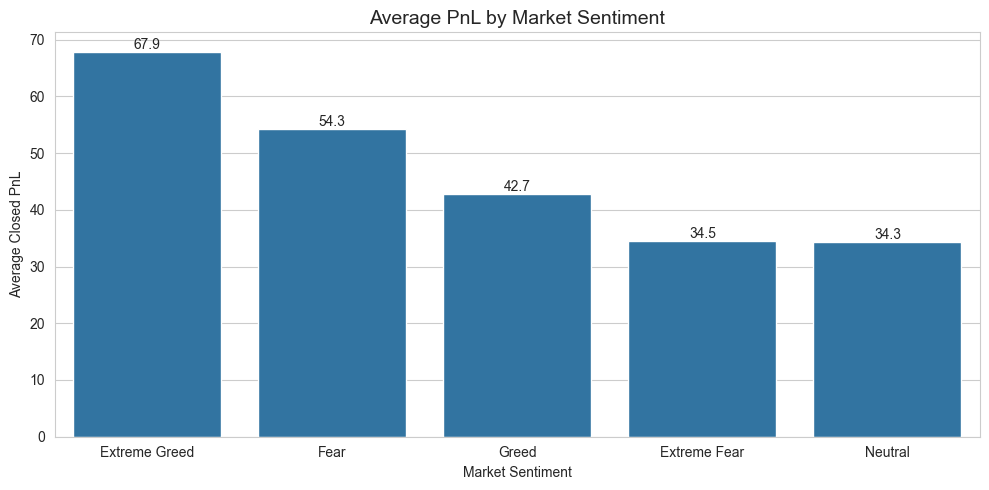

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=sentiment_summary,
    x='classification',
    y='avg_pnl'
)

plt.title('Average PnL by Market Sentiment', fontsize=14)
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')

plt.tight_layout()
plt.show()

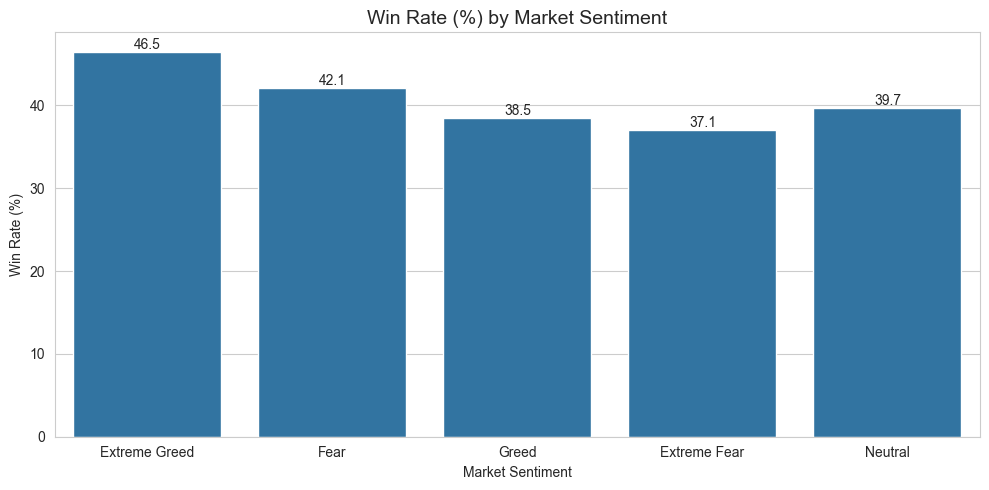

In [47]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=sentiment_summary,
    x='classification',
    y='win_rate'
)

plt.title('Win Rate (%) by Market Sentiment', fontsize=14)
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')

plt.tight_layout()
plt.show()

# Profitability Distribution Analysis

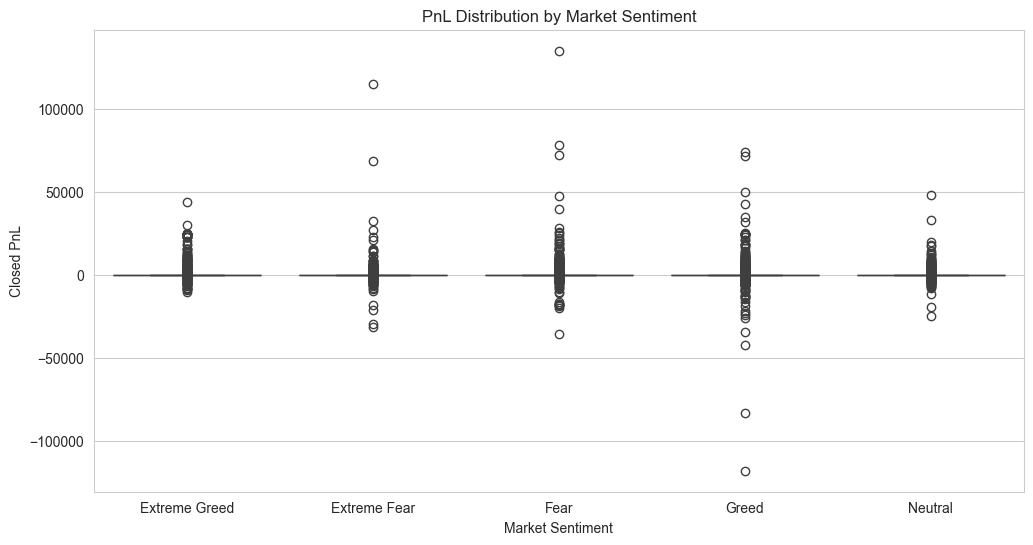

In [48]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged_df,
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')

plt.show()

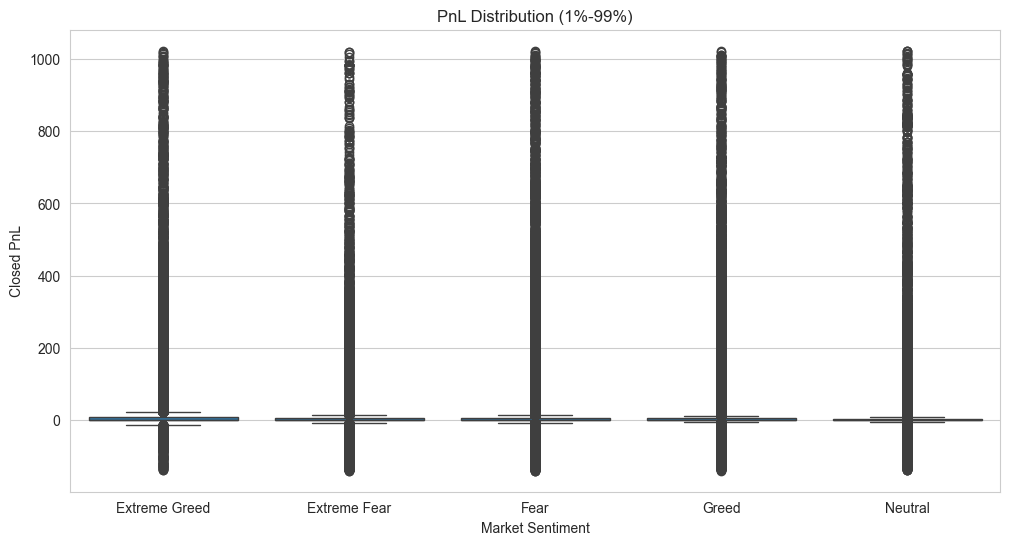

In [49]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=merged_df[
        (merged_df['Closed PnL'] >= merged_df['Closed PnL'].quantile(0.01))
        &
        (merged_df['Closed PnL'] <= merged_df['Closed PnL'].quantile(0.99))
    ],
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution (1%-99%)')
plt.xlabel('Market Sentiment')
plt.ylabel('Closed PnL')

plt.show()

In [50]:
distribution_summary = merged_df.groupby('classification')['Closed PnL'].describe()

distribution_summary

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.00,34.54,1136.06,-31036.69,0.00,0.00,5.64,115287.00
Extreme Greed,39992.00,67.89,766.83,-10259.47,0.00,0.00,10.03,44223.45
Fear,61837.00,54.29,935.36,-35681.75,0.00,0.00,5.59,135329.09
Greed,50303.00,42.74,1116.03,-117990.10,0.00,0.00,4.94,74530.52
Neutral,37686.00,34.31,517.12,-24500.00,0.00,0.00,4.00,48504.10


# Trading Activity Analysis

In [51]:
trade_activity = merged_df.groupby('classification').agg(
    total_trades=('Closed PnL', 'count'),
    unique_traders=('Account', 'nunique'),
    total_volume=('Size USD', 'sum'),
    avg_trade_size=('Size USD', 'mean')
).reset_index()

trade_activity

,classification,total_trades,unique_traders,total_volume,avg_trade_size
0,Extreme Fear,21400,32,114484261.44,5349.73
1,Extreme Greed,39992,30,124465164.57,3112.25
2,Fear,61837,32,483324789.79,7816.11
3,Greed,50303,31,288582494.72,5736.88
4,Neutral,37686,31,180242063.08,4782.73


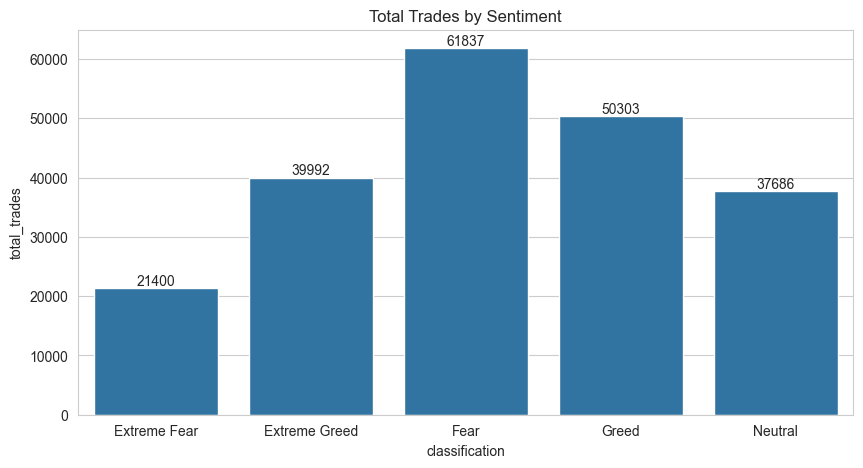

In [52]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=trade_activity,
    x='classification',
    y='total_trades'
)

plt.title('Total Trades by Sentiment')

for i in ax.containers:
    ax.bar_label(i)

plt.show()

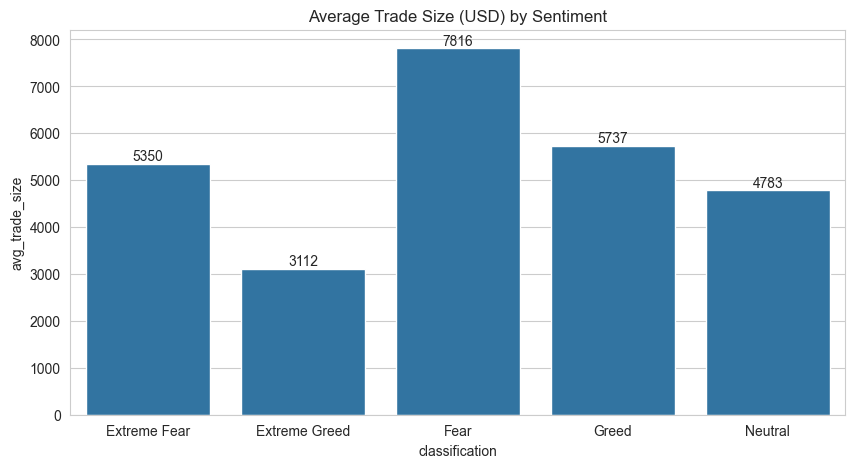

In [53]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=trade_activity,
    x='classification',
    y='avg_trade_size'
)

plt.title('Average Trade Size (USD) by Sentiment')

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.show()

# Risk Taking Behaviour Analysis

In [54]:
risk_analysis = merged_df.groupby('classification').agg(
    avg_position=('Start Position', 'mean'),
    median_position=('Start Position', 'median'),
    avg_fee=('Fee', 'mean'),
    total_fee=('Fee', 'sum')
).reset_index()

risk_analysis

,classification,avg_position,median_position,avg_fee,total_fee
0,Extreme Fear,-2322.30,1828.70,1.12,23888.63
1,Extreme Greed,19518.99,314.02,0.68,27030.67
2,Fear,8709.82,399.12,1.50,92456.95
3,Greed,-151088.55,0.51,1.25,63098.69
4,Neutral,144.00,225.22,1.04,39374.27


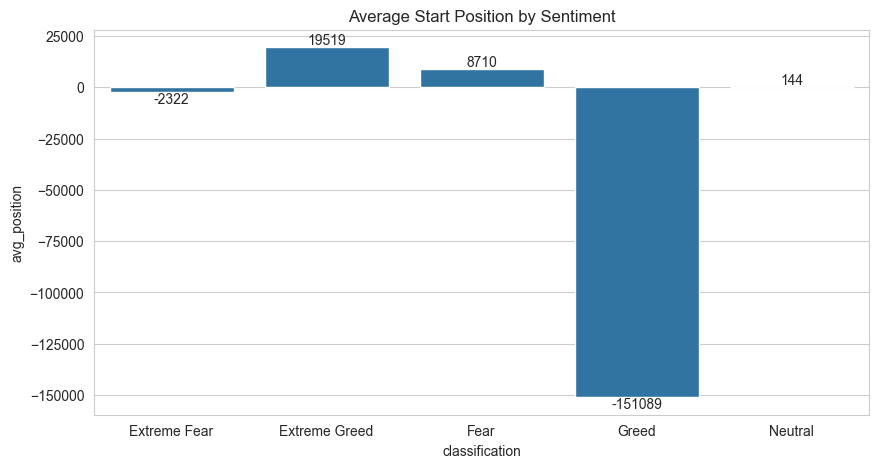

In [55]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=risk_analysis,
    x='classification',
    y='avg_position'
)

plt.title('Average Start Position by Sentiment')

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.show()

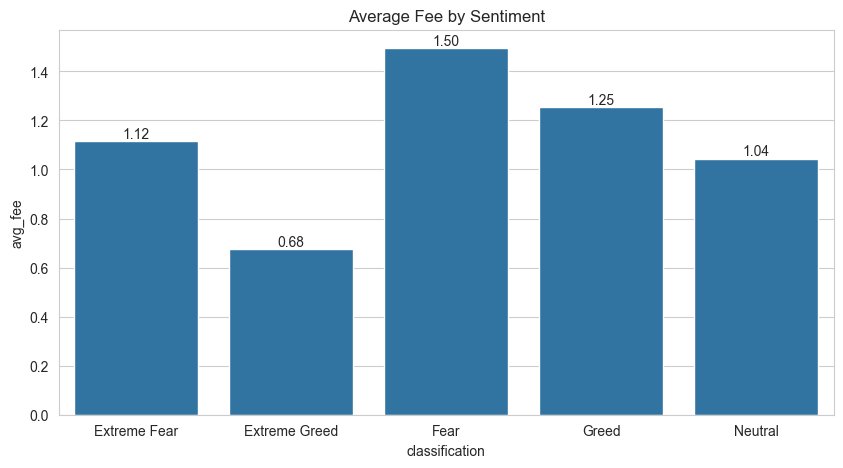

In [56]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=risk_analysis,
    x='classification',
    y='avg_fee'
)

plt.title('Average Fee by Sentiment')

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.show()

# Long vs Short Analysis

In [57]:
direction_analysis = pd.crosstab(
    merged_df['classification'],
    merged_df['Direction'],
    normalize='index'
) * 100

direction_analysis = direction_analysis.round(2)

direction_analysis

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0.00,3.77,29.16,14.57,0.00,0.02,32.73,14.83,4.87,0.00,0.03,0.01
Extreme Greed,0.00,12.83,17.97,16.25,0.00,0.02,15.75,19.16,17.91,0.00,0.03,0.08
Fear,0.00,5.19,27.91,14.91,0.00,0.02,28.82,17.61,5.44,0.00,0.03,0.07
Greed,0.02,9.31,15.90,22.51,0.00,0.03,16.99,23.19,11.90,0.00,0.05,0.11
Neutral,0.00,7.66,26.52,15.52,0.00,0.04,27.12,16.86,6.23,0.00,0.03,0.03


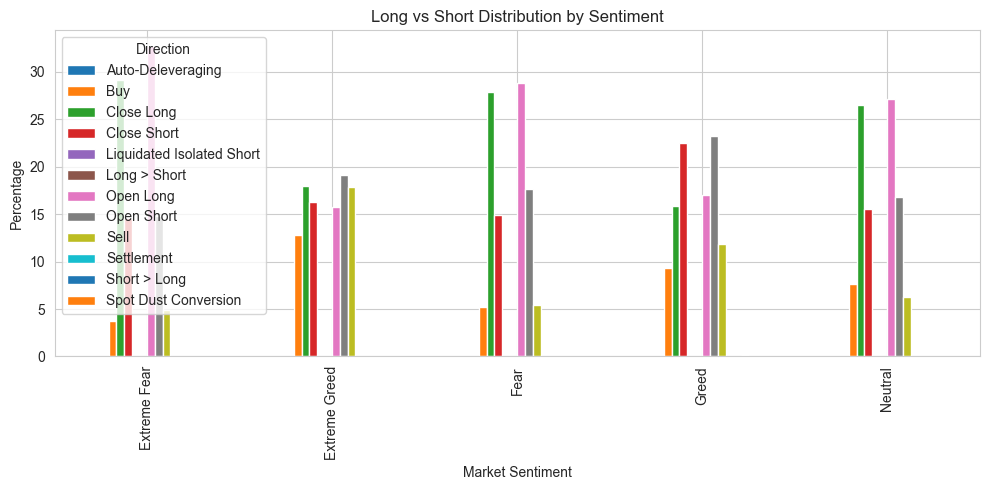

In [58]:
direction_analysis.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Long vs Short Distribution by Sentiment')
plt.ylabel('Percentage')
plt.xlabel('Market Sentiment')

plt.legend(title='Direction')
plt.tight_layout()
plt.show()

In [59]:
direction_count = pd.crosstab(
    merged_df['classification'],
    merged_df['Direction']
)

direction_count

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


# Top Trader Analysis

In [60]:
top_traders = (
    merged_df.groupby('Account')
    .agg(
        total_pnl=('Closed PnL', 'sum'),
        total_trades=('Closed PnL', 'count')
    )
    .sort_values('total_pnl', ascending=False)
    .head(10)
)

top_traders

,total_pnl,total_trades
Account,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2143382.60,14733
0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,3818
0xbaaaf6571ab7d571043ff1e313a9609a10637864,940163.81,21192
0x513b8629fe877bb581bf244e326a047b249c4ff1,840422.56,12236
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,836080.55,40184
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,677747.05,4356
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,429355.57,1590
0x430f09841d65beb3f27765503d0f850b8bce7713,416541.87,1237
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,379095.41,9893


In [61]:
top_accounts = top_traders.index.tolist()

top_trader_sentiment = (
    merged_df[merged_df['Account'].isin(top_accounts)]
    .groupby('classification')
    .agg(
        total_pnl=('Closed PnL', 'sum'),
        avg_pnl=('Closed PnL', 'mean'),
        trades=('Closed PnL', 'count')
    )
    .reset_index()
)

top_trader_sentiment

,classification,total_pnl,avg_pnl,trades
0,Extreme Fear,781134.18,60.77,12855
1,Extreme Greed,1899915.43,136.96,13872
2,Fear,2688611.74,66.98,40141
3,Greed,2111913.06,93.53,22581
4,Neutral,1141984.32,53.83,21214


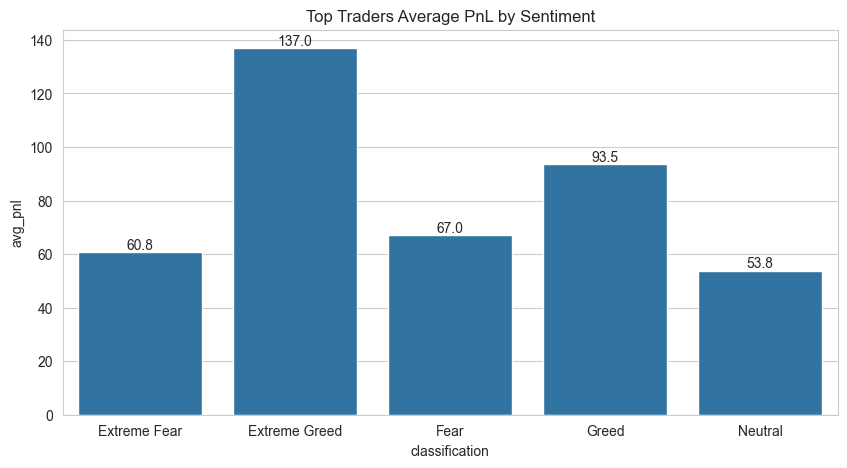

In [62]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top_trader_sentiment,
    x='classification',
    y='avg_pnl'
)

plt.title('Top Traders Average PnL by Sentiment')

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')

plt.show()

# Statistical Significance Testing

In [63]:
from scipy.stats import kruskal

In [64]:
groups = [
    group['Closed PnL'].values
    for _, group in merged_df.groupby('classification')
]

In [ ]:
stat, p_value = kruskal(*groups)

print("Statistic:", stat)
print("P-value:", p_value)

In [69]:
# Top 10 most profitable coin-sentiment combinations
top_coin_patterns = (
    coin_analysis
    .sort_values('total_pnl', ascending=False)
    .head(10)
)

top_coin_patterns

,classification,Coin,total_pnl,avg_pnl,trades
88,Extreme Greed,@107,1988618.87,191.16,10403
324,Fear,HYPE,840306.35,30.06,27951
361,Fear,SOL,741594.29,189.47,3914
387,Greed,@107,724342.31,86.25,8398
315,Fear,ETH,675064.58,236.86,2850
307,Fear,BTC,482649.64,48.90,9870
41,Extreme Fear,HYPE,482083.81,46.90,10278
539,Greed,SOL,451690.01,284.80,1586
472,Greed,ETH,351036.01,98.22,3574
694,Neutral,SOL,303376.19,216.70,1400


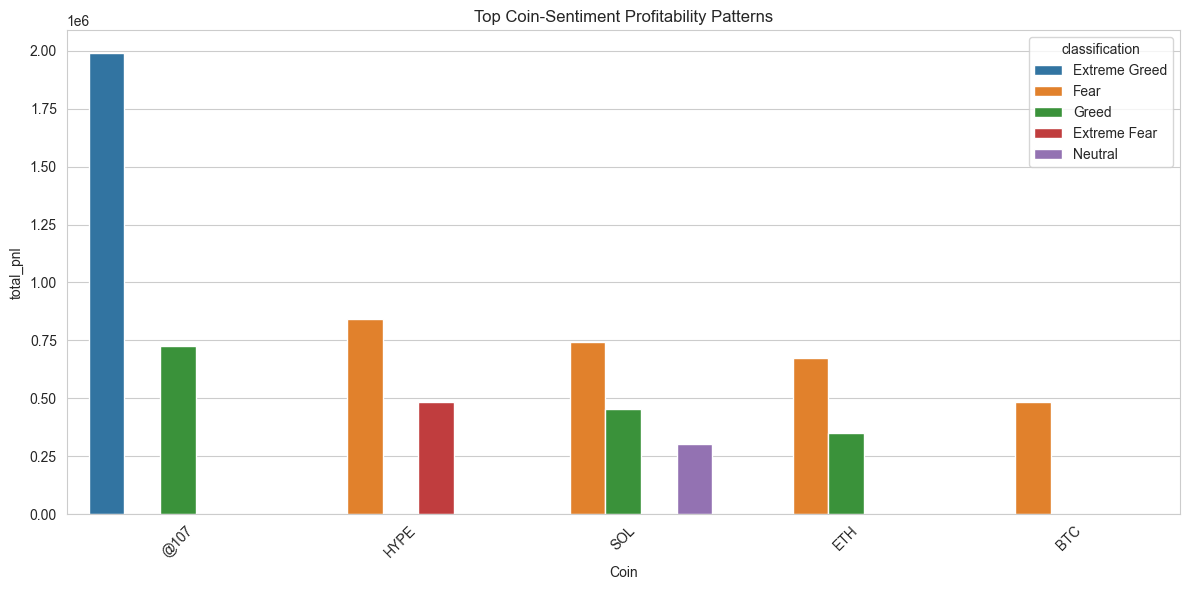

In [70]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_coin_patterns,
    x='Coin',
    y='total_pnl',
    hue='classification'
)

plt.title('Top Coin-Sentiment Profitability Patterns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Trade Size vs Profitability Analysis

In [71]:
merged_df['trade_size_bucket'] = pd.qcut(
    merged_df['Size USD'],
    q=5,
    labels=[
        'Very Small',
        'Small',
        'Medium',
        'Large',
        'Very Large'
    ]
)

In [72]:
size_analysis = (
    merged_df.groupby('trade_size_bucket')
    .agg(
        total_trades=('Closed PnL', 'count'),
        avg_pnl=('Closed PnL', 'mean'),
        total_pnl=('Closed PnL', 'sum'),
        win_rate=('is_profit', 'mean')
    )
    .reset_index()
)

size_analysis['win_rate'] *= 100

size_analysis

,trade_size_bucket,total_trades,avg_pnl,total_pnl,win_rate
0,Very Small,42244,1.43,60245.10,43.42
1,Small,42244,6.31,266600.60,39.97
2,Medium,42247,12.01,507527.81,39.63
3,Large,42247,29.88,1262500.27,42.40
4,Very Large,42236,193.14,8157613.15,40.21


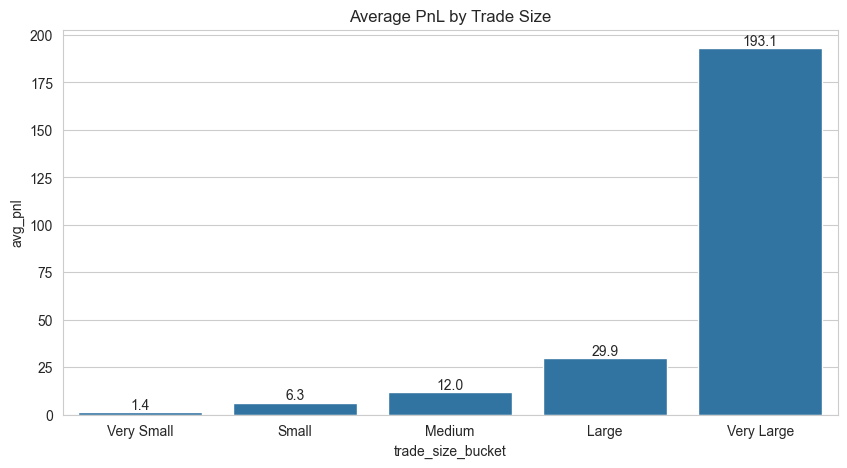

In [73]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=size_analysis,
    x='trade_size_bucket',
    y='avg_pnl'
)

plt.title('Average PnL by Trade Size')

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')

plt.show()

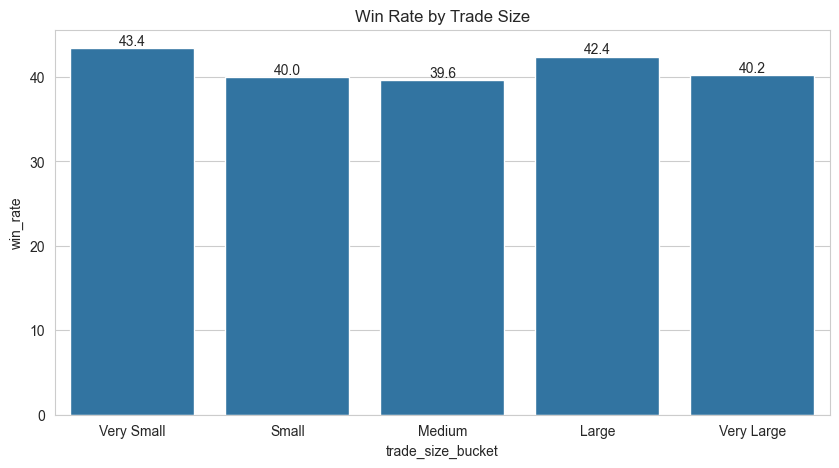

In [74]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=size_analysis,
    x='trade_size_bucket',
    y='win_rate'
)

plt.title('Win Rate by Trade Size')

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f')

plt.show()

#  Key Insights & Recommendations

## Key Insights

1. Extreme Greed delivered the highest average trader profitability (Avg PnL = 67.89).

2. Fear sentiment recorded the highest trading activity, volume, and average trade size, indicating aggressive market participation during fearful conditions.

3. Top-performing traders achieved their highest average profitability during Extreme Greed periods (Avg PnL = 136.96).

4. Coin-specific analysis revealed strong profitability patterns:
   - @107 performed exceptionally well during Extreme Greed.
   - HYPE showed strong performance during Fear.
   - SOL remained profitable across both Fear and Greed phases.

5. Larger trades generated substantially higher average profits than smaller trades, suggesting position sizing plays a major role in trader profitability.

6. Statistical testing (Kruskal-Wallis Test) confirmed significant differences in profitability across sentiment groups (p < 0.05).

## Trading Strategy Recommendations

1. Monitor Extreme Greed periods for high-profit trading opportunities while maintaining strict risk controls.

2. Fear-driven markets may provide attractive trading setups due to increased participation and liquidity.

3. Focus on historically strong sentiment-coin combinations such as:
   - @107 during Extreme Greed
   - HYPE during Fear
   - SOL during Fear and Greed

4. Position sizing appears to have a stronger impact on profitability than win rate alone.

5. Sentiment indicators should be incorporated as an additional factor in trade decision-making and risk management frameworks.

In [75]:
import os
print(os.getcwd())

C:\Users\itspa\DS_Assignment
